In [85]:
include_barmer =  False

# we want to get the normalized expressions after batchcorrections
- we will not include the QC steps for now

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 
sc.settings.seed = 1
print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.3.3


In [87]:
dataloc = "../scratch/snRNAseq_LCNE_with_chrom.h5ad"
adata_sc_orig = sc.read_h5ad(dataloc)
adata_sc_orig.obs['actualsex'].value_counts()

actualsex
M    2577
F    2291
Name: count, dtype: int64

## removing  XY genes (keeping the nan and mitochondria genes) 

In [88]:
mask_xy = adata_sc_orig.var["chromosome"].isin(["X",'Y'])
# mask_mt = adata_sc_orig.var["chromosome"].isin(["MT"])
# mask_nan_chrom = adata_sc_orig.var["chromosome"].isna()
# mask_xy_or_nan_or_mt = mask_xy | mask_nan_chrom | mask_mt
mask_xy_or_nan_or_mt = mask_xy 

print(adata_sc_orig.shape[1],'before removing genes')
adata_sc_orig = adata_sc_orig[:, ~mask_xy_or_nan_or_mt.fillna(False)].copy()
print(adata_sc_orig.shape[1],'after removing genes')

29617 before removing genes
28705 after removing genes


In [89]:
mask_xy_or_nan_or_mt.fillna(False).sum()

np.int64(912)

In [90]:
if include_barmer:
    barseq_datapath = '../data/LCNE_barseq_counts_updated.csv'
    df = pd.read_csv(barseq_datapath)
    barseq_genes = df.iloc[:,0].tolist()
    barseq_genes = list(set(barseq_genes).intersection(adata_sc_orig.var_names))

filename = '../data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

var_names = adata_mer.var_names.intersection(adata_sc_orig.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


# two ways to do the HVG
1. CPM with seurat v3 (normalized) - default 
2. log CPM with seurat 

In [91]:
sc.pp.highly_variable_genes(adata_sc_orig, n_top_genes=1500, 
                            flavor="seurat_v3",#batch_key="sex",
                            subset=False)
hvg_genes = sorted(
    set(
        adata_sc_orig.var_names[adata_sc_orig.var["highly_variable"]].tolist()
        + ["Dbh", "Th"]
    )
)

assert len(hvg_genes) == len(set(hvg_genes))
if include_barmer:
    genes_to_keep = sorted(list(set(hvg_genes) | set(adata_mer.var_names.tolist()) | set(barseq_genes)))
else:
    genes_to_keep = sorted(list(set(hvg_genes)))  # Also sort this one
print(len(genes_to_keep))  # 1769 or 1500 for now!

1502


In [92]:
'Shox2' in hvg_genes

True

In [93]:
[g for g in adata_sc_orig.var_names if 'Htr2' in g]

['Htr2b', 'Htr2a']

In [94]:

genes_of_interest = ["Dbh", "Th", "Shox2", "Pdyn","Htr2a","Htr2b"]
in_hvg = [g for g in genes_of_interest if g in hvg_genes]
not_in_hvg = [g for g in genes_of_interest if g not in hvg_genes]
print("In HVG list:", in_hvg)
print("Missing from HVG list:", not_in_hvg)

In HVG list: ['Dbh', 'Th', 'Shox2', 'Htr2a']
Missing from HVG list: ['Pdyn', 'Htr2b']


In [95]:
len([a for a in list(genes_to_keep) if 'Gm' in a])

297

In [96]:
# save raw, and change the observations columns etc
raw_adata = adata_sc_orig.copy()
adata_sc = raw_adata[:, genes_to_keep].copy()
adata_sc.raw = raw_adata[adata_sc.obs_names, :].copy()
totalcounts = np.sum(adata_sc.X, -1)
adata_sc.obs['totalcounts']=totalcounts
def batch_flag(x):
    # 1 for concatenated long strings, 0 for simple M/F
    return 1 if ';' in x else 2
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['sex'].apply(batch_flag).astype('O')
adata_sc.X = adata_sc.X.tocsr() # do this for the faster scvi implementation!

In [97]:
raw_adata.shape

(4868, 28705)

In [98]:
adata_sc.shape

(4868, 1502)

In [99]:
adata_sc_orig.shape

(4868, 28705)

# run scvi for the integrations

In [100]:
np.mean(adata_sc.X, 0) 

matrix([[ 1.06758422,  1.3147083 ,  0.07826623, ...,  8.34695974,
         12.87880033,  5.72863599]], shape=(1, 1502))

In [101]:
scvi.settings.seed = 421
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sex')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train(max_epochs=400)#,early_stopping=True)#,early_stopping_patience=45)

Seed set to 421
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [102]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [103]:
np.mean(adata_sc.obsm[SCVI_LATENT_KEY], 0)  # seed 42 results (with barmer): -0.02546425, -0.04029592, -0.09200841,  0.02213329

# no barmer seed 4 array([-0.01065198, -0.03663757, -0.02210931, -0.08312064], dtype=float32)

array([-0.0251593 ,  0.0638762 , -0.13210689, -0.00124789], dtype=float32)

In [104]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15, random_state=1)
sc.tl.umap(adata_sc,random_state=210, min_dist=.5)  

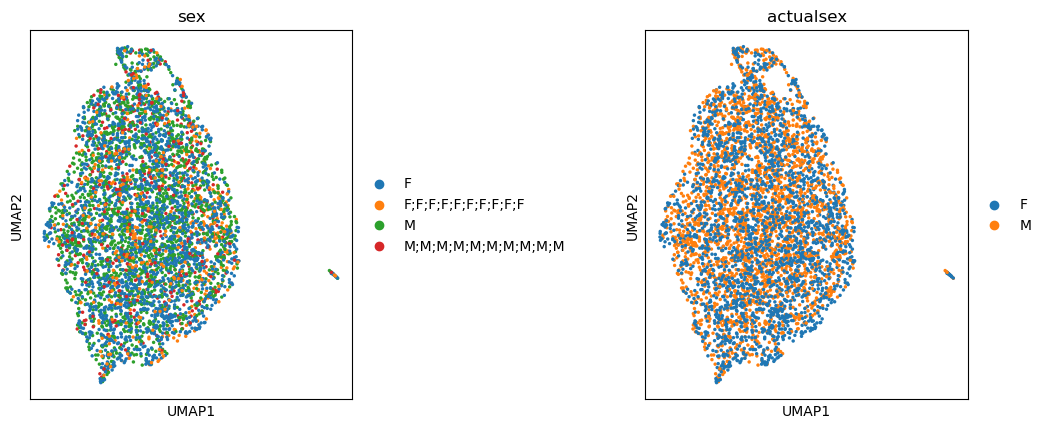

In [105]:
ax = sc.pl.umap(
    adata_sc,color=["sex",'actualsex'],
    ncols=3,show = False)
for a in ax:
    a.set_aspect('equal')

# TODO: add leiden to check the island

# investigate further on the small island 

It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


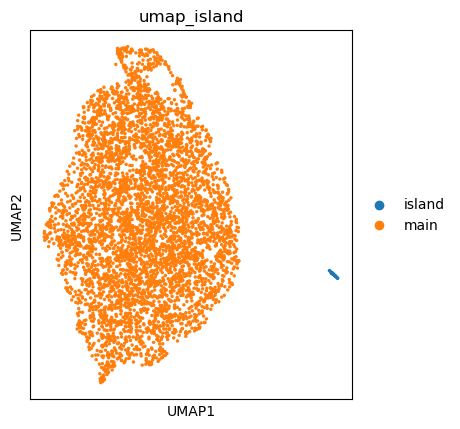

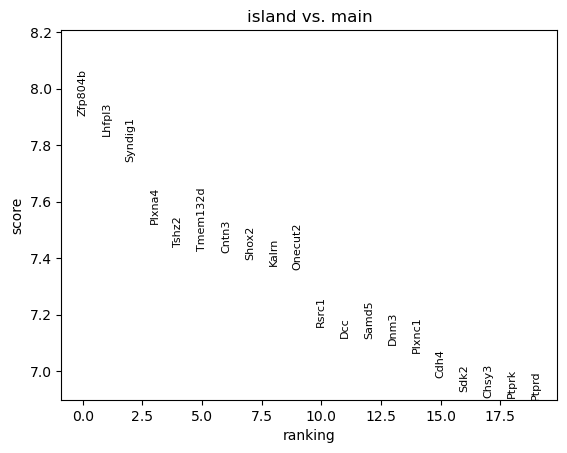

how many cells in the island?
23


In [106]:
from sklearn.cluster import KMeans
X = adata_sc.obsm["X_umap"]

# 1) many clusters on UMAP
kmeans = KMeans(n_clusters=50, random_state=0).fit(X)
labels = kmeans.labels_

# 2) smallest cluster = island
sizes = np.bincount(labels)
island_label = sizes.argmin()

adata_sc.obs["umap_island"] = pd.Categorical(
    np.where(labels == island_label, "island", "main")
)

# quick check
a=sc.pl.umap(adata_sc, color="umap_island", show = False)
a.set_aspect('equal')

# 3) DE: island vs main
sc.tl.rank_genes_groups(
    adata_sc,
    groupby="umap_island",
    groups=["island"],
    reference="main",
    method="wilcoxon",
)

sc.pl.rank_genes_groups(adata_sc, n_genes=20, sharey=False)

print('how many cells in the island?')
print((adata_sc.obs["umap_island"] == "island").sum())

### always confirm the island cells are the same cellss
todo: save this as a separate file and confirm eveyrtime

In [109]:
current_island = (
    adata_sc.obs
    .loc[adata_sc.obs["umap_island"] == "island"]
    .index.to_series(name="cell_id")
    .sort_values()
    .reset_index(drop=True)
)

# load saved reference
ref_island = pd.read_csv("../scratch/umap_island_cells_ref.csv")["cell_id"]
ref_island = ref_island.sort_values().reset_index(drop=True)

# exact match check (same cells, same counts)
same_cells = current_island.equals(ref_island)
print("Same island cells as reference:", same_cells)

Same island cells as reference: True


In [ ]:
rg = adata_sc.uns["rank_genes_groups"]
topgene = pd.DataFrame({
    k: rg[k]["island"] for k in ["names", "scores", "pvals_adj"]
}).head(8)["names"].tolist()

ax = sc.pl.umap(
    adata_sc,
    color=topgene,sort_order=True,
    ncols=4,cmap = 'Reds', show = False
)
for a in ax: a.set_aspect('equal')

In [ ]:
gene = "Shox2"
if adata_sc.raw is not None and gene in adata_sc.raw.var_names:
    expr = adata_sc.raw[:, gene].X
else:
    expr = adata_sc[:, gene].X
expr = np.asarray(expr.todense()).ravel()
ds   = adata_sc.obs["doublet_score"].values


In [ ]:
is_island = adata_sc.obs["umap_island"] == "island"

plt.figure(figsize=(4, 4))
plt.scatter(np.log1p(expr[~is_island]), ds[~is_island], s=5, alpha=0.3, label="main")
plt.scatter(np.log1p(expr[is_island]),  ds[is_island],  s=8, alpha=0.8, label="island")
plt.xlabel("log1p(Shox2 expression)")
plt.ylabel("doublet_score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ds[~is_island].astype(float).mean()

In [ ]:
ds[is_island].astype(float).mean()

In [ ]:

ax =sc.pl.umap(
    adata_sc,
    color=['Dbh','Th','Shox2','Tacr3','Trhr'],
    ncols=8,cmap = 'Reds', s = 10, show = False
)
for a in ax: a.set_aspect('equal')

In [ ]:

num_cols = adata_sc.obs.select_dtypes(include="number").columns

summary = (adata_sc.obs.groupby("umap_island")[num_cols].median().T)

summary["delta"] = summary["island"] - summary["main"]
summary.sort_values("delta", ascending=False).head(15)


In [ ]:
from scipy.stats import ranksums

stats = []
for c in num_cols:
    x = adata_sc.obs.loc[adata_sc.obs.umap_island=="island", c]
    y = adata_sc.obs.loc[adata_sc.obs.umap_island=="main", c]
    if x.nunique() > 1 and y.nunique() > 1:
        stats.append((c, ranksums(x, y).pvalue))

pd.DataFrame(stats, columns=["col", "p"]).sort_values("p").head(15)

In [ ]:
adata_sc.obs.loc[
    adata_sc.obs["umap_island"] == "island",
    "doublet_score"].astype(float).values


# get the batch average normalized expression counts
- Denoised expression with batch “removed”

In [28]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

['F', 'F;F;F;F;F;F;F;F;F;F', 'M', 'M;M;M;M;M;M;M;M;M;M']


In [29]:
X_hat_avg = model.get_normalized_expression(
    adata=adata_sc,
    transform_batch=all_batches,    
    library_size= 1, # we wont change this to 1e+6 here for now
    return_numpy=False
)  
import anndata
adata_sc_BN = anndata.AnnData(X_hat_avg.copy())
adata_sc_BN.obs = adata_sc.obs.copy()
adata_sc_BN.obsm = adata_sc.obsm.copy()
adata_sc_BN.var = adata_sc.var.copy()

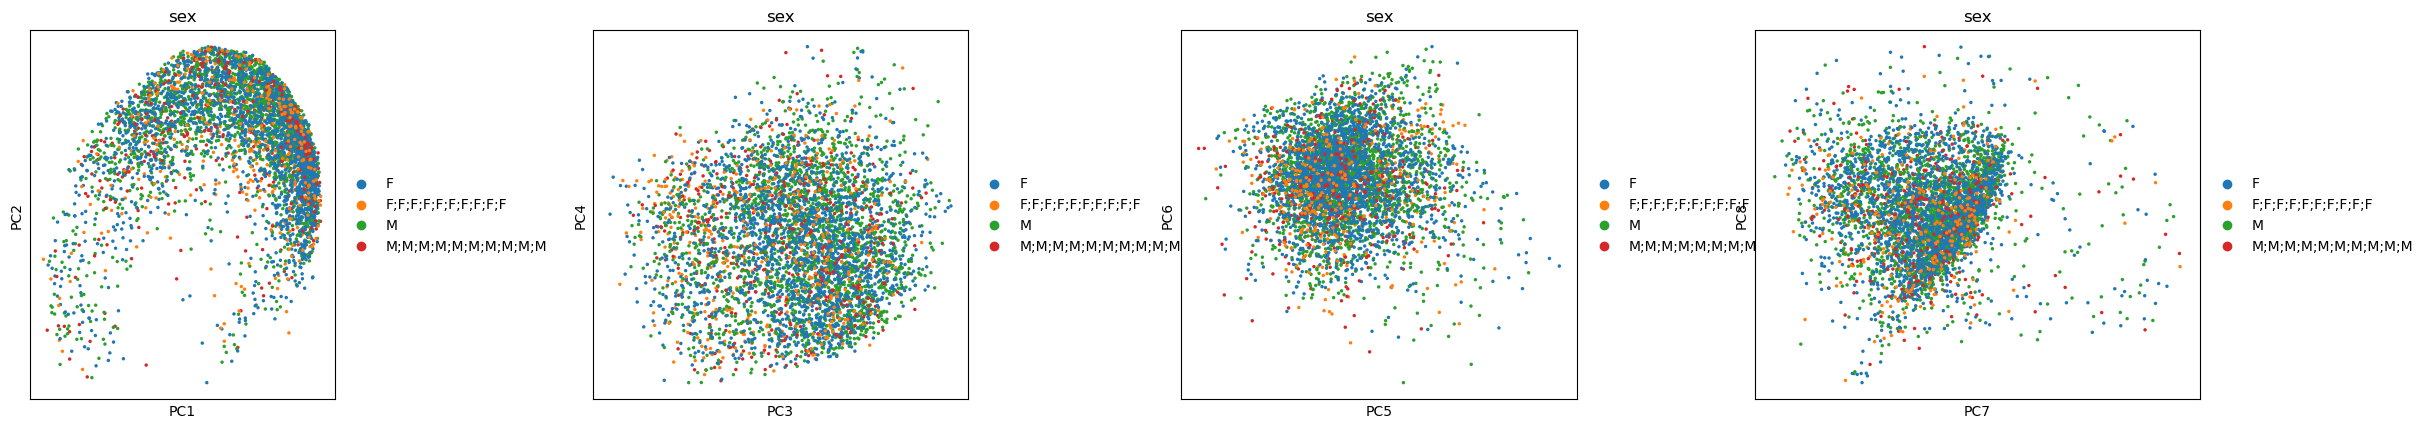

In [30]:
# standardize teh X for each genes
adata_sc_BN.X -= np.mean(adata_sc_BN.X, 0)
std_gene = np.std(adata_sc_BN.X, 0)
adata_sc_BN.X /= std_gene
sc.tl.pca(adata_sc_BN)
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='sex')
for a in ax: a.set_aspect('equal')
plt.show()


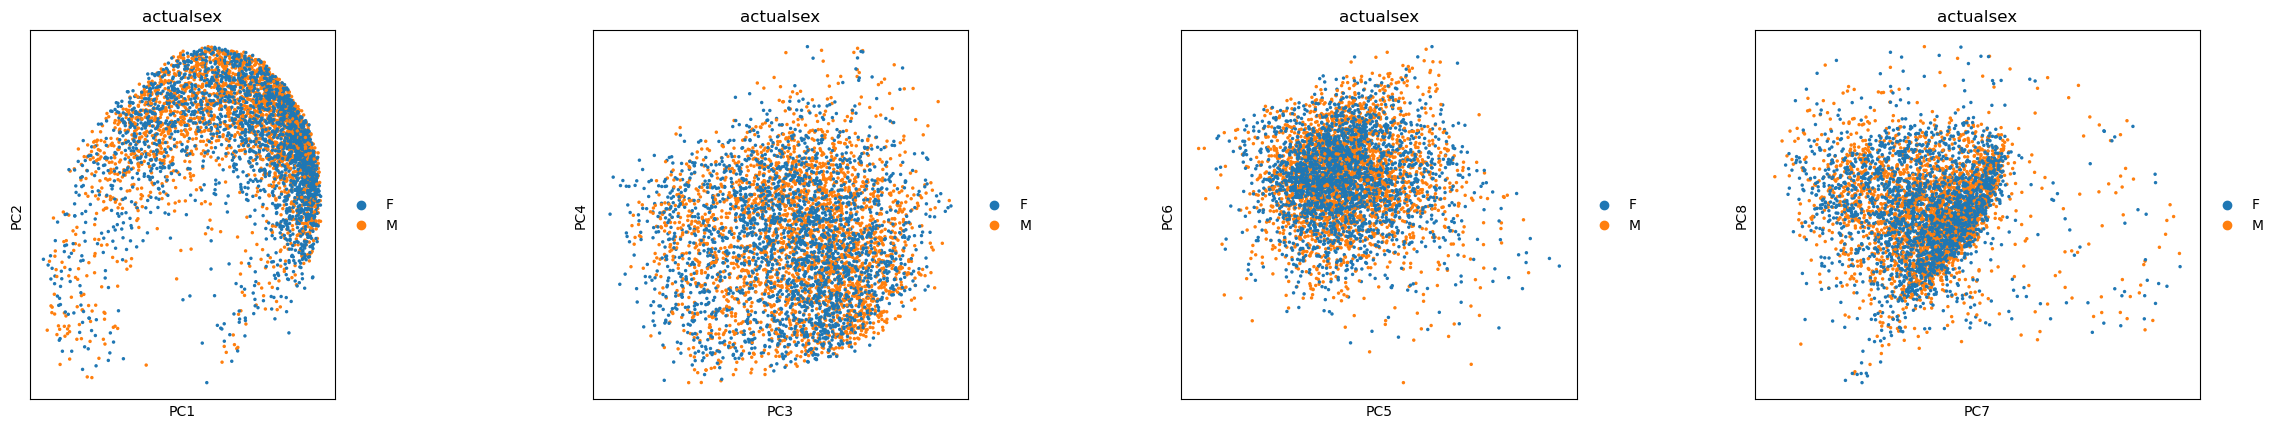

In [31]:
ax = sc.pl.pca(adata_sc_BN, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), show=False, color='actualsex')
for a in ax: a.set_aspect('equal')
plt.show()

# binary classification score 

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score

In [33]:

X_pca = np.asarray(adata_sc_BN.obsm['X_pca'])
X_scvi = np.asarray(adata_sc_BN.obsm[SCVI_LATENT_KEY])

y = (np.asarray(adata_sc_BN.obs['actualsex']) == 'F').astype(int)

for X in [X_pca, X_scvi]:
    
    print('=====')
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    yhat = (p >= 0.5).astype(int)
    print("accuracy:", accuracy_score(yte, yhat))
    print("roc_auc:", roc_auc_score(yte, p))
    print("confusion_matrix:\n", confusion_matrix(yte, yhat))
    
    
    scores = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                             X, y, cv=5, scoring="roc_auc")
    print("cv_roc_auc_mean:", scores.mean())


=====
accuracy: 0.553388090349076
roc_auc: 0.5544962932872957
confusion_matrix:
 [[358 158]
 [277 181]]
cv_roc_auc_mean: 0.5582884175541085
=====
accuracy: 0.5328542094455853
roc_auc: 0.542627196100335
confusion_matrix:
 [[369 147]
 [308 150]]
cv_roc_auc_mean: 0.5653889792179807


In [34]:
(np.sum(adata_sc.X, axis = 0)<3).sum()

np.int64(0)

# save 
- the normalized counts are saved as `BN` layer
- for now we keep 1e+6 

In [35]:
cpm_scl= 1
adata_sc.layers["BN"] = X_hat_avg*cpm_scl

# discard the 23 small island cell. only keep the main island here. 


In [36]:
filename = 'snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad' if include_barmer else 'snRNAseq_LCNE_BN_d4_1-5k.h5ad' 
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['experimental_batch_id'].astype(str)


adata_sc_final = adata_sc[adata_sc.obs["umap_island"] != "island"].copy()
adata_sc_final.write(f"../results/{filename}")



In [37]:
filename

'snRNAseq_LCNE_BN_d4_1-5k.h5ad'

In [38]:
adata_sc

AnnData object with n_obs × n_vars = 4868 × 1502
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'X', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'cell_prep_sample_name', 'injection_roi', 'injection_method', 'injection_materials', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 

In [39]:
adata_sc_final

AnnData object with n_obs × n_vars = 4845 × 1502
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'X', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'cell_prep_sample_name', 'injection_roi', 'injection_method', 'injection_materials', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 